# Convection speed analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from globals import main_dir,data_dir, plot_dir, res_dir
import pickle
import pandas as pd
from Rotor import Rotor
import plotting_routines

In [2]:
# j = 1.2
# R = 0.7
# n_elem=40
# Vinf = np.array([60,0,0])
# n = Vinf[0]/(j*2*R)
# Ome  = n*2*np.pi
# Vinf = np.array([60,0,0])
# Vinf_wing = np.array([1,0,0])
# c_R_func:Callable = lambda r_R : 0.18-0.06*r_R
# twst_func:Callable = lambda r_R : -50*r_R+35
# wing_c_R_func:Callable = lambda r_R: np.ones(shape=r_R.shape)/10 #=1
# wing_twst_func:Callable = lambda r_R : r_R*0

R = 0.7
J = 1.2
Vinf = 60
n = Vinf/(J*2*R)
const_rotor_inputs = dict(
        B=6,
        R=R,
        r_R_H=0.25,
        c_R_func= lambda r_R : 0.18-0.06*r_R,
        twst_func= lambda r_R : -50*r_R+35 ,
        pitch=45,
        polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
        Omega = n*2*np.pi,
        Vinf = np.array([Vinf,0,0]),
        rho = 1.067,
        dist_elem="uniform",
        n_elems_per_wake = 80,
        n_elem = 80,
        periods = 15,
)

In [4]:
a_wake_lst = np.linspace(0,0.5,11)
perf_lst = []
rotor_lst =[]
for a_wake in a_wake_lst:
    print(a_wake)
    rotor = Rotor(**const_rotor_inputs,
                  a_wake=a_wake)
    rotor.solve()
    perf_dict = rotor.calculate_spanwise_performance()
    perf_lst.append(perf_dict)
    rotor_lst.append(rotor)

0.0


MemoryError: Allocation failed (probably too large).

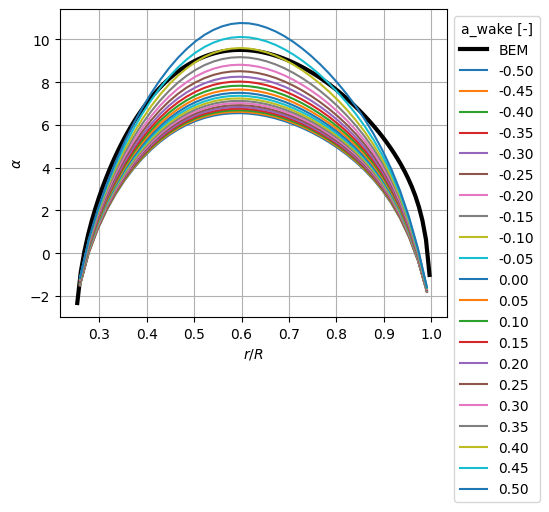

In [ ]:
a_wake_dir = res_dir.joinpath('sensitivity/a_wake')

bem_data = pd.read_csv("data/BEM_data_1.2.csv")

fig, ax = plt.subplots(figsize=(5,4))
plt.plot(bem_data["r_R"], bem_data["alpha"],label = "BEM",color="black",linewidth=3)
for i in range(len(perf_lst)):
    plt.plot(perf_lst[i]["r_R"][:n_elem],perf_lst[i]["alpha"][:n_elem],label=f"{a_wake_lst[i]:.2f}")

plt.xlabel(r"$r/R$")
plt.ylabel(r"$\alpha$")
ax.grid(True)
lgd = ax.legend(title='a_wake [-]', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(a_wake_dir.joinpath(f'dist_plot_alpah_aw.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')

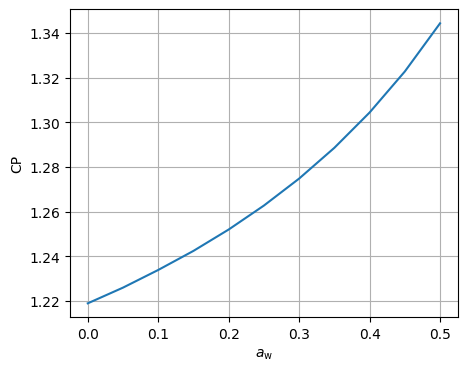

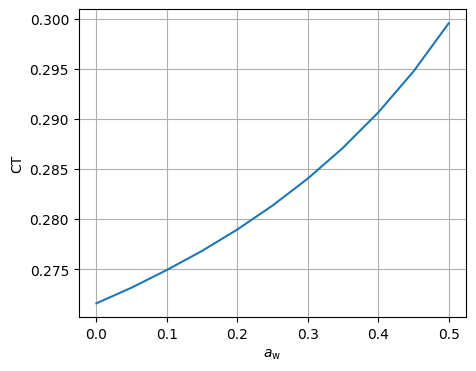

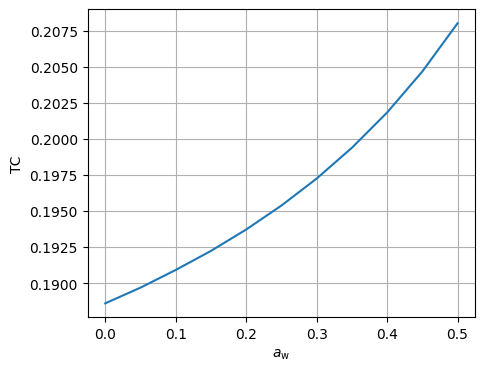

In [ ]:
cols = ["CP","CT","TC"]
labels = ["CP","CT","TC"]

for i in range(len(cols)):
    col_lst = [ getattr(rotor,cols[i]) for rotor in rotor_lst]

    fig, ax = plt.subplots(figsize=(5,4))
    plt.plot(a_wake_lst,col_lst)
    plt.xlabel(r"$a_\text{w}$")
    plt.ylabel(rf"{labels[i]}")
    ax.grid(True)
    plt.show()
    fig.savefig(a_wake_dir.joinpath(f'total_plot_{cols[i]}_aw.pdf'),
            bbox_inches='tight')